# Traffic Collision Data Analysis

# Objective

In this case study, you will be working on California Traffic Collision Data Analysis using Apache Spark, a powerful distributed computing framework designed for big data processing. This assignment aims to provide hands-on experience in analyzing large-scale traffic collision datasets using PySpark and AWS services. You will apply data analytics techniques to clean, transform, and explore crash data, drawing meaningful insights to support traffic safety and urban planning. Beyond understanding how big data tools optimize performance on a single machine and across clusters, you will develop a structured approach to analyzing crash trends, identifying high-risk locations, and evaluating contributing factors to traffic incidents. Additionally, you will utilize AWS S3 to store the processed data efficiently after the ETL process, enabling scalable storage and easy retrieval for further analysis.


# Business Value:

Traffic collisions pose significant risks to public safety, requiring continuous monitoring and analysis to enhance road safety measures. Government agencies, city planners, and policymakers must leverage data-driven insights to improve infrastructure, optimize traffic management, and implement preventive measures.

In this assignment, you will analyze California traffic collision data to uncover patterns related to accident severity, location-based risks, and key contributing factors. With Apache Spark's ability to handle large datasets efficiently and AWS S3's scalable storage, transportation authorities can process vast amounts of crash data in real time, enabling faster and more informed decision-making.

As an analyst examining traffic safety trends, your task is to analyze historical crash data to derive actionable insights that can drive policy improvements and safety interventions. Your analysis will help identify high-risk areas, categorize accidents by severity and contributing factors, and store the processed data in an AWS S3 bucket for scalable and long-term storage.

By leveraging big data analytics and cloud-based storage, urban planners and traffic authorities can enhance road safety strategies, reduce accident rates, and improve public transportation planning.


# Dataset Overview

The dataset used in this analysis consists of California traffic collision data obtained from the Statewide Integrated Traffic Records System (SWITRS). It includes detailed records of traffic incidents across California, covering various attributes such as location, severity, involved parties, and contributing factors. The dataset has been preprocessed and transformed using PySpark to facilitate large-scale analysis. By leveraging Apache Spark, we ensure efficient data handling, enabling deeper insights into traffic patterns, accident trends, and potential safety improvements.

The dataset is a .sqlite file contains detailed information about traffic collisions across California and is structured into four primary tables:
- `collisions` table contains information about the collision, where it happened, what vehicles were involved.

- `parties` table contains information about the groups people involved in the collision including age, sex, and sobriety.

- `victims` table contains information about the injuries of specific people involved in the collision.

- `locations` table contains information about the geographical location and details of road intersections.

# Assignment Tasks

<ol>
    <li>
        <strong>Data Preparation</strong></br>
        The dataset consists of structured tables containing traffic collision data. Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.</br>
        Check for data consistency and ensure all columns are correctly formatted.</br>
        Apply sampling techniques if needed to extract a representative subset for analysis.</br>
        Structure and prepare the data for further processing and analysis.</br>
    </br>
    <li>
        <strong>Data Cleaning</strong></br>
            2.1 <strong>Fixing Columns:</strong> Ensure all columns are properly named and formatted.</br>
            2.2 <strong>Handling Missing Values:</strong> Decide on an approach to handle missing data (e.g., imputation or removal). Mention the approach in your report.</br>
            2.3 <strong>Handling Outliers:</strong> Identify outliers in the dataset and explain why they are considered outliers. It is not necessary to remove them for this task, but mention your approach for handling them.</br>
    </br>
    <li>
        <strong>Exploratory Data Analysis</strong></br>
        Finding Patterns and analyze the dataset and find patterns based on the following points:
                <ul>
                3.1 Classify variables into categorical and numerical types.</br>
                3.2 Analyze the distribution of collision severity.</br>
                3.3 Examine weather conditions during collisions.</br>
                3.4 Analyze the distribution of victim ages.</br>
                3.5 Study the relationship between collision severity and the number of victims.</br>
                3.6 Analyze the correlation between weather conditions and collision severity.</br>
                3.7 Visualize the impact of lighting conditions on collision severity.</br>
                3.8 Extract and analyze weekday-wise collision trends.</br>
                3.9 Assess the number of collisions occurring on different days of the week.</br>
                3.10 Study spatial distribution of collisions by county.</br>
                3.11 Generate a scatter plot to analyze collision locations geographically.</br>
                3.12 Extract and analyze collision trends over time, including yearly, monthly, and hourly trends.</br>
</ul>
</br>
<li>
<strong>ETL Querying</strong><br>
Write PySpark SQL queries for the following:</br>
<ol>
    4.1. Identify the top 5 counties with the highest number of collisions.</br>
    4.2. Identify the month with the highest number of collisions.</br>
    4.3. Determine the most common weather condition during collisions.</br>
    4.4. Calculate the percentage of collisions that resulted in fatalities.</br>
    4.5. Find the most dangerous time of day for collisions.</br>
    4.6. Identify the top 5 road surface conditions with the highest collision frequency.</br>
    4.7. Analyze lighting conditions that contribute to the highest number of collisions.</br>
</ol>
</br>
<li>
<strong>Conclusion</strong></br>
Provide final insights and recommendations based on the analysis:
    <ul>
        5.1 Recommendations to improve road safety by identifying high-risk locations and peak accident times for infrastructure improvements.</br>
        5.2 Suggestions to optimize traffic management by analyzing trends in collision severity, weather conditions, and lighting to improve road design and traffic signal timing.</br>
        5.3 Propose data-driven policy changes to enhance pedestrian and cyclist safety based on collision trends involving vulnerable road users.</br>
        5.4 Identify potential high-risk zones for proactive intervention by examining geographic collision density and historical accident data.</br>
        5.5 Assess the impact of environmental factors such as weather, road surface conditions, and lighting on accident frequency and severity.</br>
        5.6 Develop predictive models to anticipate collision hotspots and support proactive safety measures.</br>
        </ul>
        Conclude the analysis by summarizing key findings and business implications.</br>
        Explain the results of univariate, segmented univariate, and bivariate analyses in real-world traffic safety and policy terms.</br>
        Include visualizations and summarize the most important results in the report. Insights should explain why each variable is important and how they can influence traffic safety policies and urban planning.</br>
        </ul>
        </br>
    <li>
    <strong>Visualization Integration [Optional]</strong>
    <p>Enhance the project by incorporating a visualization component that connects the processed data stored in an S3 bucket to a business intelligence tool such as Tableau or Power BI. This involves setting up the connection between the S3 bucket and the chosen visualization tool, importing the processed dataset for analysis and visualization, creating interactive dashboards to explore key trends and insights and ensuring data updates are reflected dynamically in the visualization tool.<br>
</br>
</ol>

In [1]:
#from google.colab import drive
#drive.mount('/content/drive')

Install Required Libraries

In [2]:
## Install the required libraries
# !pip install --quiet pyspark==3.5.4 pandas==2.2.2

In [3]:
# Import the necessary libraries
import sqlite3
import pandas as pd
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, sum, to_date, desc, when

In [4]:
spark = SparkSession.builder.appName("Collision Analysis").getOrCreate()

#**1. Data Preparation** <font color = red>[5 marks]</font> <br>

The dataset consists of structured tables containing traffic collision data.

Before conducting any analysis, it is essential to ensure that the data is properly formatted and structured for efficient processing.

Check for data consistency and ensure all columns are correctly formatted.

In [5]:
# Write code to load the data and check the schema
case = spark.read.option('header',True).csv("sample_case_ids.csv")
collision = spark.read.option('header',True).csv("sample_collisions.csv")
parties = spark.read.option('header',True).csv("sample_parties.csv")
victims = spark.read.option('header',True).csv("sample_victims.csv")

print('Case dataset schema :', case.schema)
print('Collision dataset schema :' ,collision.schema)
print('Parties dataset schema :', parties.schema)
print('Victims dataset schema :', victims.schema)

Case dataset schema : StructType([StructField('case_id', StringType(), True), StructField('db_year', StringType(), True)])
Collision dataset schema : StructType([StructField('case_id', StringType(), True), StructField('jurisdiction', StringType(), True), StructField('officer_id', StringType(), True), StructField('reporting_district', StringType(), True), StructField('chp_shift', StringType(), True), StructField('population', StringType(), True), StructField('county_city_location', StringType(), True), StructField('county_location', StringType(), True), StructField('special_condition', StringType(), True), StructField('beat_type', StringType(), True), StructField('chp_beat_type', StringType(), True), StructField('chp_beat_class', StringType(), True), StructField('beat_number', StringType(), True), StructField('primary_road', StringType(), True), StructField('secondary_road', StringType(), True), StructField('distance', StringType(), True), StructField('direction', StringType(), True), S

#**2. Data Cleaning** <font color = red>[20 marks]</font> <br>


In [6]:
#Display Schema & Sample Data
case.show(5)
collision.show(5)
parties.show(5)
victims.show(5)

+----------+-------+
|   case_id|db_year|
+----------+-------+
|90017156.0|   2021|
| 4078685.0|   2021|
|90588783.0|   2021|
| 3351919.0|   2018|
|  632208.0|   2018|
+----------+-------+
only showing top 5 rows

+----------+------------+----------+------------------+--------------+----------------+--------------------+---------------+-----------------+-------------------+----------------+--------------+-----------+------------------+--------------+--------+---------+------------+---------+-----------------------+---------------+-----------------+-----------+--------+-------------+---------------+--------+--------------------+--------------+---------------+-----------+------------------------+----------------------+-------------+------------------------+---------------+-----------------+---------------------------+--------------------+------------+----------------+--------------------+--------------+-------------+--------------------+-----------------+--------------------+------------

In [7]:
print('Number of columns in collision dataset is ',len(collision.columns))
print('Number of columns in case dataset is ',len(case.columns))
print('Number of columns in parties dataset is ',len(parties.columns))
print('Number of columns in victims dataset is ',len(victims.columns))

Number of columns in collision dataset is  65
Number of columns in case dataset is  2
Number of columns in parties dataset is  24
Number of columns in victims dataset is  11


In [8]:
print('Number of rows in collision dataset is ',collision.count())
print('Number of rows in case dataset is ',case.count())
print('Number of rows in parties dataset is ',parties.count())
print('Number of rows in victims dataset is ',victims.count())

Number of rows in collision dataset is  935791
Number of rows in case dataset is  942433
Number of rows in parties dataset is  1866917
Number of rows in victims dataset is  963933


##**2.1 Missing Values** <font color = red>[10 marks]</font> <br>


In [9]:
#Check for Missing Values
def get_null_count(df):
    null_count = df.select([sum(col(col1).isNull().cast('int')).alias(col1) for col1 in df.columns]).toPandas().T
    print(null_count[null_count[0]>0])


In [10]:
get_null_count(collision)

                                      0
jurisdiction                       1158
officer_id                         2264
reporting_district               552653
population                          165
special_condition                 51730
chp_beat_class                      274
beat_number                       80780
primary_road                         10
secondary_road                        2
direction                        232663
intersection                       9484
weather_1                          4626
state_highway_indicator             318
caltrans_county                  682075
caltrans_district                648728
state_route                      648728
postmile                         648728
location_type                    682075
side_of_highway                  682077
tow_away                           6153
killed_victims                      200
injured_victims                     230
primary_collision_factor           5660
pcf_violation_category            15424


In [11]:
get_null_count(case)

Empty DataFrame
Columns: [0]
Index: []


In [12]:
get_null_count(parties)

                                   0
party_type                      4395
party_sex                     249269
party_age                     290783
party_sobriety                 55663
direction_of_travel            52377
party_safety_equipment_1      314883
party_safety_equipment_2      699581
financial_responsibility      152613
cellphone_in_use              568197
cellphone_use_type            432264
other_associate_factor_1      112496
movement_preceding_collision   33275
vehicle_year                  177599
vehicle_make                  195057
statewide_vehicle_type        210693
chp_vehicle_type_towing       401142
chp_vehicle_type_towed        909543
party_race                    436844


In [13]:
get_null_count(victims)

                                0
victim_role                     1
victim_sex                  24041
victim_age                  32145
victim_seating_position      1913
victim_safety_equipment_1   55215
victim_safety_equipment_2  310220
victim_ejected               4272


In [14]:
#Drop Sparse Columns

parties_sparse_columns = ['party_safety_equipment_2', 'chp_vehicle_type_towed', 'party_race', 'chp_vehicle_type_towing',\
                         'cellphone_in_use', 'cellphone_use_type']
victims_sparse_columns = ['victim_safety_equipment_2']
collision_sparse_columns = ['latitude', 'Longitude', 'pcf_violation_subsection', 'caltrans_county', 'caltrans_district', 'state_route', \
                            'postmile', 'location_type', 'side_of_highway', 'reporting_district', 'chp_vehicle_type_at_fault', 'direction',\
                            'statewide_vehicle_type_at_fault','beat_number']
parties = parties.drop(*parties_sparse_columns)
victims = victims.drop(*victims_sparse_columns)
collision = collision.drop(*collision_sparse_columns)

In [15]:
#Convert Data Types

from pyspark.sql.types import IntegerType, DateType, TimestampType

parties_numerical_columns = ['party_number', 'at_fault', 'party_age',  'party_number_killed', \
                             'party_number_injured', 'vehicle_year']
victims_numerical_columns = ['party_number', 'victim_age']
collision_numerical_columns = ['special_condition', 'distance', 'intersection', 'state_highway_indicator', 'tow_away', 'killed_victims',\
                               'injured_victims', 'party_count', 'chp_road_type', 'pedestrian_collision', 'bicycle_collision', 'motorcycle_collision',\
                               'truck_collision', 'not_private_property', 'severe_injury_count', 'other_visible_injury_count',
                               'complaint_of_pain_injury_count',	'pedestrian_killed_count',	'pedestrian_injured_count',
                               'bicyclist_killed_count',	'bicyclist_injured_count',	'motorcyclist_killed_count',	'motorcyclist_injured_count']
collision_date_columns = ['collision_date', 'process_date']
collision_time_columns = ['collision_time']

case_numerical_columns = ['db_year']

for column in parties_numerical_columns:
        parties = parties.withColumn(column, col(column).cast(IntegerType()))

for column in victims_numerical_columns:
        victims = victims.withColumn(column, col(column).cast(IntegerType()))

for column in collision_numerical_columns:
        collision = collision.withColumn(column, col(column).cast(IntegerType()))

for column in collision_date_columns:
        collision = collision.withColumn(column, col(column).cast(DateType()))

for column in collision_time_columns:
        collision = collision.withColumn(column, col(column).cast(TimestampType()))

In [16]:
#Handle Missing Values

# Handling null values in Collision dataset
get_null_count(collision)

                                 0
jurisdiction                  1158
officer_id                    2264
population                     165
special_condition            51730
chp_beat_class                 274
primary_road                    10
secondary_road                   2
intersection                  9484
weather_1                     4626
state_highway_indicator        318
tow_away                      6153
killed_victims                 200
injured_victims                230
primary_collision_factor      5660
pcf_violation_category       15424
pcf_violation                64175
type_of_collision             7655
motor_vehicle_involved_with   4887
pedestrian_action              615
road_surface                  8141
road_condition_1              7903
lighting                      5301
control_device                5791
collision_time                8084


In [17]:
collision = collision.na.drop(subset=["primary_road","secondary_road","state_highway_indicator", "killed_victims","injured_victims",\
                                    "pedestrian_action","collision_time", "jurisdiction", "officer_id", "population", "chp_beat_class"])
get_null_count(collision)

                                 0
special_condition            51246
intersection                  9245
weather_1                     4372
tow_away                      5899
primary_collision_factor      5413
pcf_violation_category       15001
pcf_violation                62346
type_of_collision             7428
motor_vehicle_involved_with   4723
road_surface                  7779
road_condition_1              7630
lighting                      4848
control_device                5568


In [18]:
def get_mode_value(df, column):
    mode = df.groupBy(column).count().orderBy(desc('count')).first()[0]
    return mode

In [19]:
collision = collision.na.fill({"special_condition": get_mode_value(collision,'special_condition')})
collision = collision.na.fill({'intersection': get_mode_value(collision,'intersection')})
collision = collision.na.fill({'weather_1': get_mode_value(collision,'weather_1')})
collision = collision.na.fill({'primary_collision_factor':get_mode_value(collision,'primary_collision_factor')})
collision = collision.na.fill({'tow_away':get_mode_value(collision,'tow_away')})
collision = collision.na.fill({'pcf_violation_category':get_mode_value(collision,'pcf_violation_category')})
collision = collision.na.fill({'pcf_violation':get_mode_value(collision,'pcf_violation')})
collision = collision.na.fill({'type_of_collision':get_mode_value(collision,'type_of_collision')})
collision = collision.na.fill({'motor_vehicle_involved_with':get_mode_value(collision,'motor_vehicle_involved_with')})
collision = collision.na.fill({'road_surface':get_mode_value(collision,'road_surface')})
collision = collision.na.fill({'road_condition_1':get_mode_value(collision,'road_condition_1')})
collision = collision.na.fill({'control_device':get_mode_value(collision,'control_device')})
collision = collision.na.fill({'lighting':get_mode_value(collision,'lighting')})

In [20]:
get_null_count(collision)

Empty DataFrame
Columns: [0]
Index: []


In [21]:
# Handling null values in Victims dataset
get_null_count(victims)


                               0
victim_role                    1
victim_sex                 24041
victim_age                 32145
victim_seating_position     1913
victim_safety_equipment_1  55215
victim_ejected              4272


In [22]:
victims = victims.na.drop(subset=['victim_role','victim_seating_position','victim_ejected'])

In [23]:
victims = victims.na.fill({'victim_sex':get_mode_value(victims,'victim_sex')})
victims = victims.na.fill({'victim_safety_equipment_1':get_mode_value(victims,'victim_safety_equipment_1')})

# Median of age
median_age = int(victims.approxQuantile("victim_age", [0.5], 0.01)[0])
victims = victims.na.fill({'victim_age':median_age})

In [24]:
get_null_count(victims)

Empty DataFrame
Columns: [0]
Index: []


In [25]:
# Handling null values in parties dataset
get_null_count(parties)

                                   0
party_type                      4395
party_sex                     249269
party_age                     290783
party_sobriety                 55663
direction_of_travel            52377
party_safety_equipment_1      314883
financial_responsibility      152613
other_associate_factor_1      112496
movement_preceding_collision   33275
vehicle_year                  177599
vehicle_make                  195057
statewide_vehicle_type        210693


In [26]:
parties =parties.na.drop(subset = ['party_type', 'movement_preceding_collision'])

parties = parties.na.fill({'party_sex':get_mode_value(parties,'party_sex')})
parties = parties.na.fill({'party_sobriety':get_mode_value(parties,'party_sobriety')})
parties = parties.na.fill({'direction_of_travel':get_mode_value(parties,'direction_of_travel')})
parties = parties.na.fill({'party_safety_equipment_1':get_mode_value(parties,'party_safety_equipment_1')})
parties = parties.na.fill({'financial_responsibility':get_mode_value(parties,'financial_responsibility')})
parties = parties.na.fill({'vehicle_make':get_mode_value(parties,'vehicle_make')})
parties = parties.na.fill({'statewide_vehicle_type':get_mode_value(parties,'statewide_vehicle_type')})

parties = parties.drop('other_associate_factor_1')

median_year = int(parties.approxQuantile("vehicle_year", [0.5], 0.01)[0])
parties = parties.na.fill({'vehicle_year':median_year})

median_age = int(parties.approxQuantile("party_age", [0.5], 0.01)[0])
parties = parties.na.fill({'party_age':median_age})

In [27]:
get_null_count(parties)

Empty DataFrame
Columns: [0]
Index: []


##**2.2 Fixing Columns** <font color = red>[5 marks]</font> <br>


In [28]:
#Remove Duplicates
before = collision.count()
collision = collision.drop_duplicates()
after = collision.count()

print('Number of duplicate rows removed from collision is ',before-after)

before = case.count()
case = case.drop_duplicates()
after = case.count()

print('Number of duplicate rows removed from case is ',before-after)

before = victims.count()
victims = victims.drop_duplicates()
after = victims.count()

print('Number of duplicate rows removed from victims is ',before-after)

before = parties.count()
parties = parties.drop_duplicates()
after = parties.count()

print('Number of duplicate rows removed from parties is ',before-after)

Number of duplicate rows removed from collision is  0
Number of duplicate rows removed from case is  35
Number of duplicate rows removed from victims is  0
Number of duplicate rows removed from parties is  0


In [29]:
#Detect Outliers using IQR


# List of numerical columns to check for outliers

parties_numerical_columns = ['party_number', 'party_age', 'party_number_killed', \
                             'party_number_injured']
victims_numerical_columns = [ 'party_number','victim_age']
collision_numerical_columns = ['distance', 'state_highway_indicator', 'killed_victims',\
                               'injured_victims', 'party_count', 
                                 'severe_injury_count', 'other_visible_injury_count',
                               'complaint_of_pain_injury_count',	'pedestrian_killed_count',	'pedestrian_injured_count',
                               'bicyclist_killed_count',	'bicyclist_injured_count',	'motorcyclist_killed_count',	'motorcyclist_injured_count']

parties_lb_ub_dict = {}
for column in parties_numerical_columns:
    q1, q3 = parties.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3-q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    parties_lb_ub_dict[column]={'lower_bound':lower_bound,'upper_bound':upper_bound}

victims_lb_ub_dict = {}
for column in victims_numerical_columns:
    q1, q3 = victims.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3-q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    victims_lb_ub_dict[column]={'lower_bound':lower_bound,'upper_bound':upper_bound}

collision_lb_ub_dict = {}
for column in collision_numerical_columns:
    q1, q3 = collision.approxQuantile(column, [0.25, 0.75], 0.01)
    iqr = q3-q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    collision_lb_ub_dict[column]={'lower_bound':lower_bound,'upper_bound':upper_bound}

print('Parties bound: ', parties_lb_ub_dict)
print('Victims bound: ',victims_lb_ub_dict)
print('Collision bound: ',collision_lb_ub_dict)

Parties bound:  {'party_number': {'lower_bound': -0.5, 'upper_bound': 3.5}, 'party_age': {'lower_bound': -3.0, 'upper_bound': 77.0}, 'party_number_killed': {'lower_bound': 0.0, 'upper_bound': 0.0}, 'party_number_injured': {'lower_bound': 0.0, 'upper_bound': 0.0}}
Victims bound:  {'party_number': {'lower_bound': -0.5, 'upper_bound': 3.5}, 'victim_age': {'lower_bound': -19.5, 'upper_bound': 80.5}}
Collision bound:  {'distance': {'lower_bound': -675.0, 'upper_bound': 1125.0}, 'state_highway_indicator': {'lower_bound': -1.5, 'upper_bound': 2.5}, 'killed_victims': {'lower_bound': 0.0, 'upper_bound': 0.0}, 'injured_victims': {'lower_bound': -1.5, 'upper_bound': 2.5}, 'party_count': {'lower_bound': 2.0, 'upper_bound': 2.0}, 'severe_injury_count': {'lower_bound': 0.0, 'upper_bound': 0.0}, 'other_visible_injury_count': {'lower_bound': 0.0, 'upper_bound': 0.0}, 'complaint_of_pain_injury_count': {'lower_bound': -1.5, 'upper_bound': 2.5}, 'pedestrian_killed_count': {'lower_bound': 0.0, 'upper_boun

##**2.3 Outlier Analysis** <font color = red>[5 marks]</font> <br>


In [30]:
#Remove Outliers

# Removing outliers in parties dataset
parties_numerical_columns = ['party_number', 'party_age', 'party_number_killed'] # removable outliers column
parties_cleaned = parties
for column in parties_numerical_columns:
    parties_cleaned = parties_cleaned.filter((col(column) >= parties_lb_ub_dict[column]['lower_bound']) & (col(column) <= parties_lb_ub_dict[column]['upper_bound']))
    print(column,  parties_cleaned.count())

# Median using approxQuantile
median_value = parties_cleaned.approxQuantile("party_number_injured", [0.5], 0.01)[0]

parties_cleaned = parties_cleaned.withColumn(
    "party_number_injured",
    when((col("party_number_injured") < parties_lb_ub_dict[column]['lower_bound']) | (col("party_number_injured") > \
                                                                                       parties_lb_ub_dict[column]['upper_bound']), median_value)
    .otherwise(col("party_number_injured"))
)

party_number 1796801
party_age 1768203
party_number_killed 1762673


In [31]:
parties_cleaned.count()

1762673

In [32]:
parties = parties_cleaned

In [33]:
# Calculate the median victim_age to replace outliers
median_victim_age = int(victims.approxQuantile("victim_age", [0.5], 0.01)[0])
victims = victims.withColumn(
    'victim_age',
    when((col('victim_age') < victims_lb_ub_dict['victim_age']['lower_bound']) | (col('victim_age') > victims_lb_ub_dict['victim_age']['upper_bound']), median_victim_age)
    .otherwise(col("victim_age"))
)

# Calculate the median party_number to replace outliers
median_party_number = int(victims.approxQuantile("party_number", [0.5], 0.01)[0])
victims = victims.withColumn(
    'party_number',
    when((col('party_number') < victims_lb_ub_dict['party_number']['lower_bound']) | (col('party_number') > victims_lb_ub_dict['party_number']['upper_bound']), \
median_party_number)
    .otherwise(col("victim_age"))
)

In [34]:
# Handling collision outliers

print('Collision dataset count before handling outliers:', collision.count())

# Loop through each numerical column in collision_numerical_columns
for column in collision_numerical_columns:
    # Get the upper and lower bounds from the pre-calculated dictionary
    lower_bound = collision_lb_ub_dict[column]['lower_bound']
    upper_bound = collision_lb_ub_dict[column]['upper_bound']

    # Calculate the median for the current column
    median_value = int(collision.approxQuantile(column, [0.5], 0.01)[0])

    # Replace outliers (values less than 0 or outside the IQR bounds) with the median
    collision = collision.withColumn(
        column,
        when((col(column) < 0) | (col(column) < lower_bound) | (col(column) > upper_bound), median_value)
        .otherwise(col(column))
    )

print('Collision dataset count after handling outliers:', collision.count())

Collision dataset count before handling outliers: 922578
Collision dataset count after handling outliers: 922578


#**3. Exploratory Data Analysis** <font color = red>[65 marks]</font> <br>


##**3.1.1. Data Preparation** <font color = red>[5 marks]</font> <br>

Q: Classify variables into categorical and numerical.

In [35]:
# Categorical variables

parties_categorical_columns = ['party_type','party_sex','party_sobriety','direction_of_travel',
                               'financial_responsibility','movement_preceding_collision','statewide_vehicle_type']
victims_categorical_columns = ['victim_role','victim_sex','victim_degree_of_injury','victim_seating_position',\
                               'victim_ejected']
collision_categorical_columns = ['chp_shift','population','beat_type','chp_beat_type','chp_beat_class','weather_1', \
                                 'collision_severity', 'primary_collision_factor', 'pcf_violation_category', 'hit_and_run',\
                                 'type_of_collision','road_surface',  'road_condition_1','lighting']

# Numerical variables


parties_numerical_columns = ['party_number', 'at_fault', 'party_age',  'party_number_killed', \
                             'party_number_injured', 'vehicle_year']
victims_numerical_columns = ['party_number', 'victim_age']
collision_numerical_columns = ['special_condition', 'distance', 'intersection', 'state_highway_indicator', 'tow_away', \
                               'killed_victims','injured_victims', 'party_count', 'chp_road_type', 'pedestrian_collision', \
                               'bicycle_collision', 'motorcycle_collision','truck_collision', 'not_private_property', \
                               'severe_injury_count', 'other_visible_injury_count', 'complaint_of_pain_injury_count',	\
                               'pedestrian_killed_count',	'pedestrian_injured_count', 'bicyclist_killed_count',\
                               'bicyclist_injured_count',	'motorcyclist_killed_count',	'motorcyclist_injured_count']

In [36]:
# Encode Categorical Variables
# String Indexing for Categorical Columns

def encode_categorical(df, columns):
    for column in columns:
        indexer = StringIndexer(inputCol=column, outputCol=column + "_indexed", handleInvalid="keep")
        df = indexer.fit(df).transform(df)
    return df
from pyspark.ml.feature import StringIndexer

# String Indexing for Categorical Columns
collision = encode_categorical(collision, collision_categorical_columns)
parties = encode_categorical(parties, parties_categorical_columns)
victims = encode_categorical(victims, victims_categorical_columns)

In [37]:
# Reordering & Renaming Columns
collision = collision.withColumnRenamed('county_city_location','country_city_location')
collision = collision.withColumnRenamed( 'county_location', 'country_location')
collision = collision.withColumnRenamed( 'weather_1', 'weather')
collision = collision.withColumnRenamed('road_condition_1','road_condition')

victims = victims.withColumnRenamed( 'victim_safety_equipment_1', 'victim_safety_equipment')

parties = parties.withColumnRenamed('party_safety_equipment_1','party_safety_equipment')

In [38]:
# Final cleaned data
collision.coalesce(1).write.mode("overwrite").option("header", True).csv("cleaned_collision")
case.coalesce(1).write.mode("overwrite").option("header", True).csv("cleaned_case")
victims.coalesce(1).write.mode("overwrite").option("header", True).csv("cleaned_victims")
parties.coalesce(1).write.mode("overwrite").option("header", True).csv("cleaned_parties")

Loading the Final Cleaned Dataset into S3 Bucket

##**3.1.2. Analyze the distribution of collision severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of collision severity.

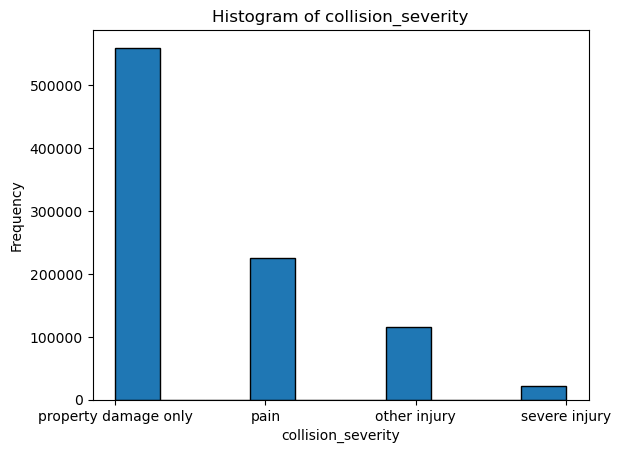

In [39]:
# Univariate Analysis

# Collision Severity Distribution

import matplotlib.pyplot as plt
import seaborn as sns

# Convert to Pandas
pdf = collision.select("collision_severity").toPandas()

# Plot

plt.hist(pdf["collision_severity"], bins=10, edgecolor="black")
plt.xlabel("collision_severity")
plt.ylabel("Frequency")
plt.title("Histogram of collision_severity")
plt.show()

##**3.1.3. Weather conditions during collisions.** <font color = red>[5 marks]</font> <br>

Q: Examine weather conditions during collisions.

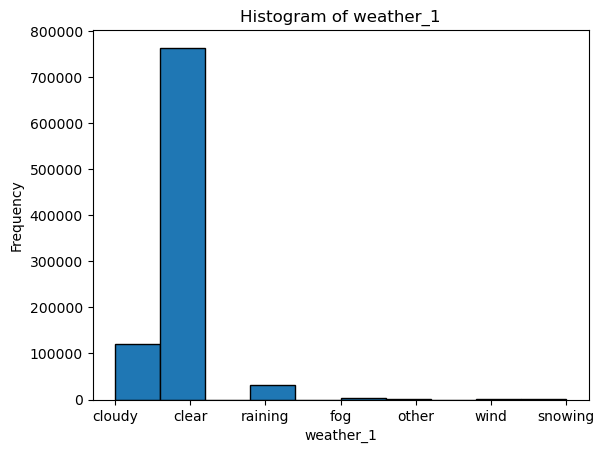

In [40]:
# Weather Conditions During Collisions

# Convert to Pandas

# Plot
pdf = collision.select("weather").toPandas()

# Plot histogram
plt.hist(pdf["weather"], edgecolor="black")
plt.xlabel("weather_1")
plt.ylabel("Frequency")
plt.title("Histogram of weather_1")
plt.show()

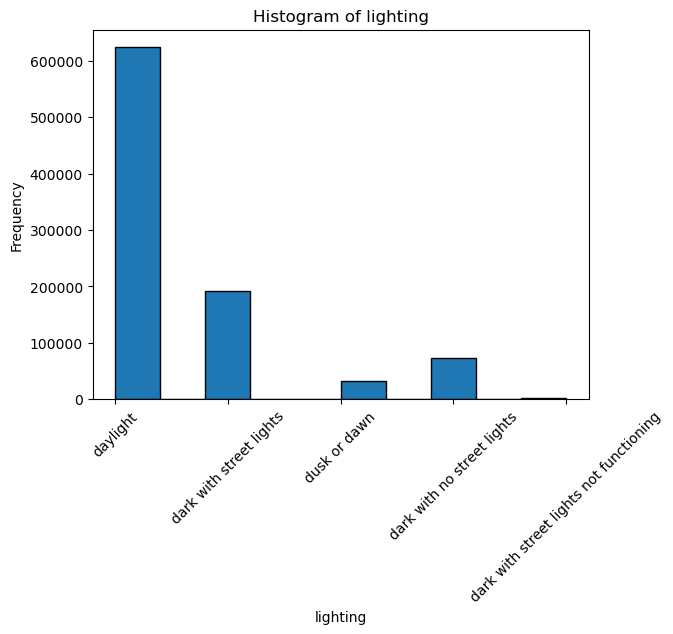

In [41]:
pdf = collision.select("lighting").toPandas()

# Plot histogram
plt.hist(pdf["lighting"], edgecolor="black")
plt.xlabel("lighting")
plt.ylabel("Frequency")
plt.title("Histogram of lighting")
plt.xticks(rotation=45)
plt.show()

##**3.1.4. Victime Age Distribution.** <font color = red>[5 marks]</font> <br>

Q: Analyze the distribution of victim ages.

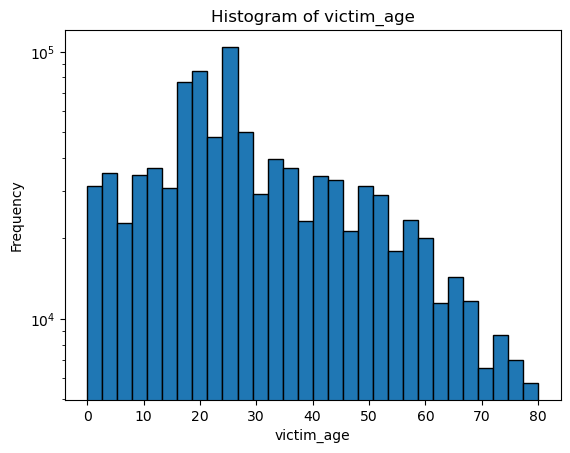

In [42]:
# Distribution of Victim Ages

# Convert to Pandas

# Plot
pdf = victims.select("victim_age").toPandas()

# Plot histogram
plt.hist(pdf["victim_age"], bins=30, edgecolor="black")
plt.xlabel("victim_age")
plt.ylabel("Frequency")
plt.title("Histogram of victim_age")
plt.yscale("log") 
plt.show()

In [43]:
from pyspark.sql import functions as F

# Get max value of victim_age
victims.agg(F.max("victim_age")).show()

+---------------+
|max(victim_age)|
+---------------+
|             80|
+---------------+



##**3.1.5. Collision Severity vs Number of Victims.** <font color = red>[5 marks]</font> <br>

Q: Study the relationship between collision severity and the number of victims.

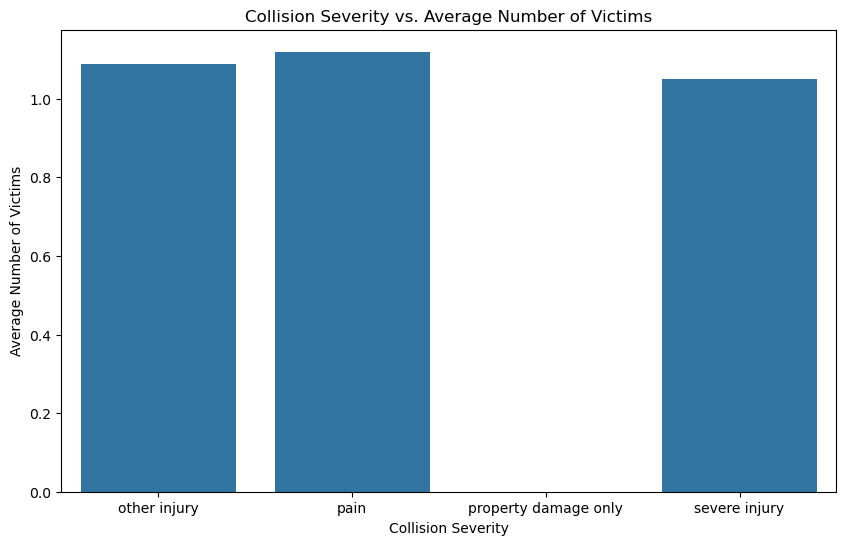

In [44]:
# Bivariate Analysis

# Collision Severity vs. Number of Victims

# Convert to Pandas

# Plot

# Calculate total victims for each collision
collision_victims = collision.withColumn("total_victims", col("injured_victims") + col("killed_victims"))

# Group by collision_severity and calculate the average number of victims
severity_victims_df = collision_victims.groupBy("collision_severity").agg({"total_victims": "avg"}).orderBy("collision_severity")

# Convert to Pandas for plotting
pdf = severity_victims_df.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="collision_severity", y="avg(total_victims)", data=pdf)
plt.xlabel("Collision Severity")
plt.ylabel("Average Number of Victims")
plt.title("Collision Severity vs. Average Number of Victims")
plt.show()

##**3.1.6. Weather Conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q: Analyze the correlation between weather conditions and collision severity.

<Figure size 1400x800 with 0 Axes>

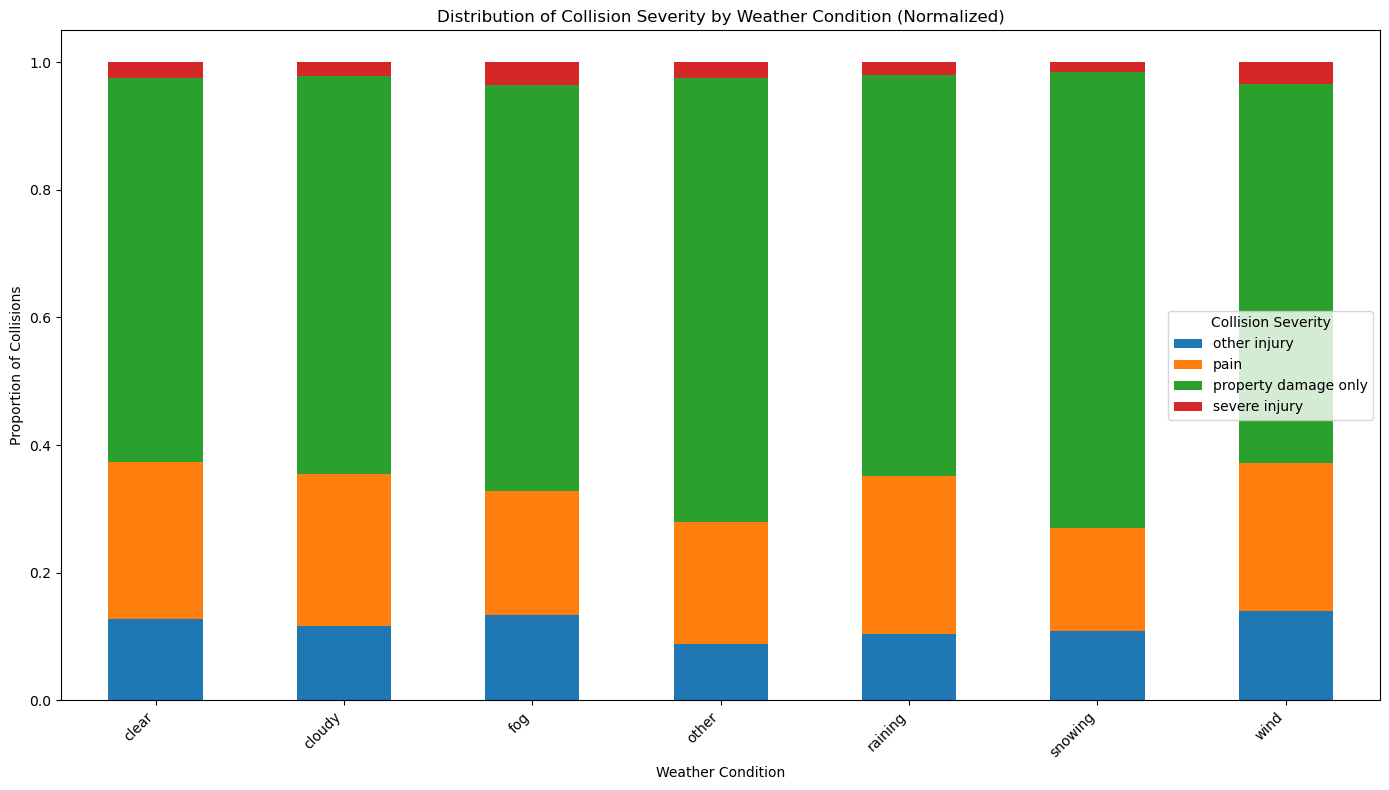

In [45]:
# Weather vs. Collision Severity

# Convert to Pandas

# Plot
from pyspark.sql.functions import count

# Group by weather and collision_severity and count occurrences
weather_severity_counts = collision.groupBy('weather', 'collision_severity').agg(count('*').alias('count'))

# Convert to Pandas for plotting
pdf = weather_severity_counts.toPandas()

# Create a pivot table to get counts for each severity by weather
pivot_df = pdf.pivot_table(index='weather', columns='collision_severity', values='count', fill_value=0)

# Normalize the counts to show percentages or proportions for each weather condition
pivot_df_normalized = pivot_df.div(pivot_df.sum(axis=1), axis=0)

# Plotting the normalized data
plt.figure(figsize=(14, 8))
pivot_df_normalized.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Distribution of Collision Severity by Weather Condition (Normalized)')
plt.xlabel('Weather Condition')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Collision Severity')
plt.tight_layout()
plt.show()

##**3.1.7. Lighting conditions vs Collision Severity.** <font color = red>[5 marks]</font> <br>

Q:Visualize the impact of lighting conditions on collision severity.

<Figure size 1400x800 with 0 Axes>

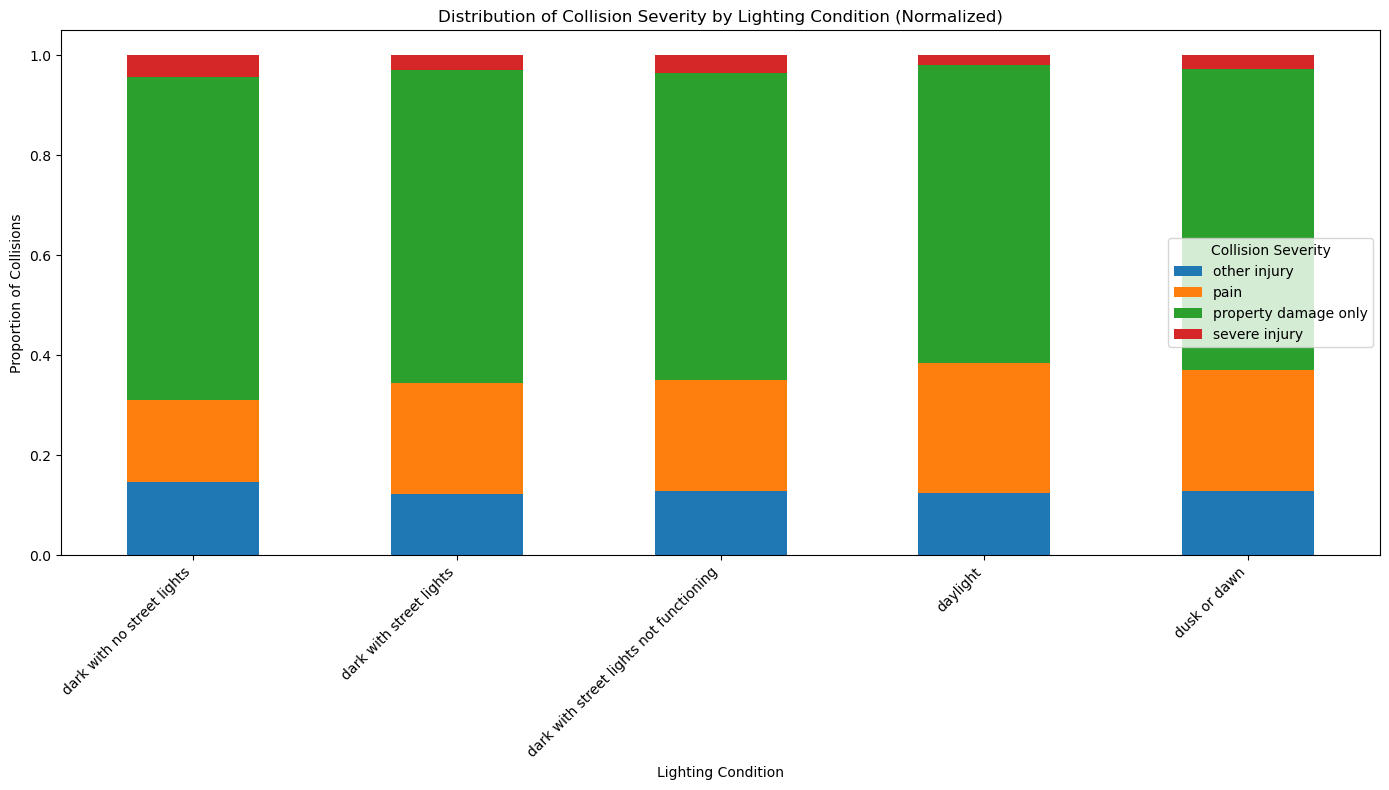

In [46]:
# Lighting Conditions vs. Collision Severity

# Convert to Pandas

# Plot
# Group by lighting and collision_severity and count occurrences
lighting_severity_counts = collision.groupBy('lighting', 'collision_severity').agg(count('*').alias('count'))

# Convert to Pandas for plotting
pdf_lighting = lighting_severity_counts.toPandas()

# Create a pivot table to get counts for each severity by lighting condition
pivot_lighting_df = pdf_lighting.pivot_table(index='lighting', columns='collision_severity', values='count', fill_value=0)

# Normalize the counts to show percentages or proportions for each lighting condition
pivot_lighting_df_normalized = pivot_lighting_df.div(pivot_lighting_df.sum(axis=1), axis=0)

# Plotting the normalized data
plt.figure(figsize=(14, 8))
pivot_lighting_df_normalized.plot(kind='bar', stacked=True, figsize=(14, 8))
plt.title('Distribution of Collision Severity by Lighting Condition (Normalized)')
plt.xlabel('Lighting Condition')
plt.ylabel('Proportion of Collisions')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Collision Severity')
plt.tight_layout()
plt.show()

##**3.1.8. Weekday-Wise Collision Trends.** <font color = red>[7 marks]</font> <br>

Q: Extract and analyze weekday-wise collision trends.

/tmp/ipykernel_126/2030109046.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="weekday", y="count", data=pdf_weekday, palette="viridis")


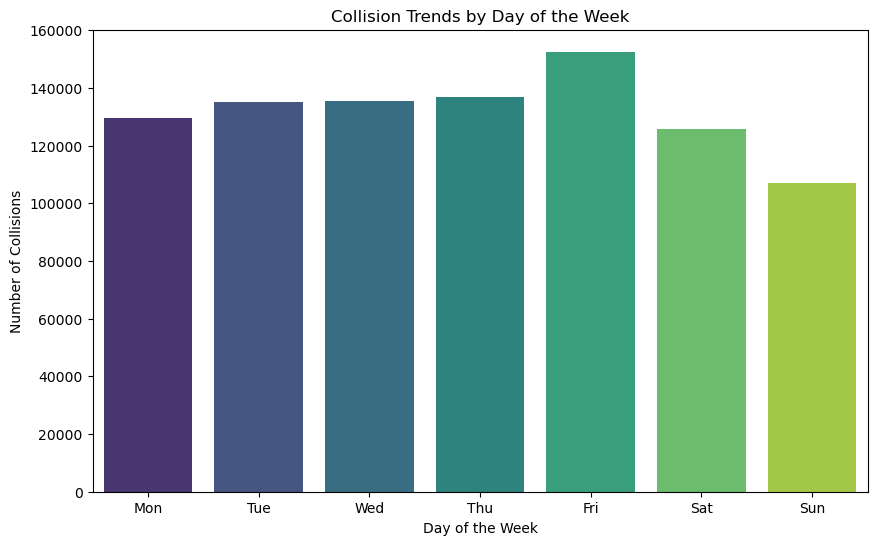

In [47]:
# Extract the weekday

# Plot
from pyspark.sql.functions import date_format

# Extract the weekday from collision_date
collision_weekday = collision.withColumn("weekday", date_format(col("collision_date"), "E"))

# Count collisions per weekday
weekday_counts = collision_weekday.groupBy("weekday").count().orderBy("count", ascending=False)

# Convert to Pandas for plotting
pdf_weekday = weekday_counts.toPandas()

# Define the order of weekdays for plotting
weekday_order = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
pdf_weekday["weekday"] = pd.Categorical(pdf_weekday["weekday"], categories=weekday_order, ordered=True)
pdf_weekday = pdf_weekday.sort_values("weekday")

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="weekday", y="count", data=pdf_weekday, palette="viridis")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Collisions")
plt.title("Collision Trends by Day of the Week")
plt.show()


##**3.1.9. Spatial Distribution of Collisions.** <font color = red>[7 marks]</font> <br>

Q: Study spatial distribution of collisions by county.

/tmp/ipykernel_126/4286444939.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="country_location", y="count", data=pdf_county.head(10), palette="viridis")


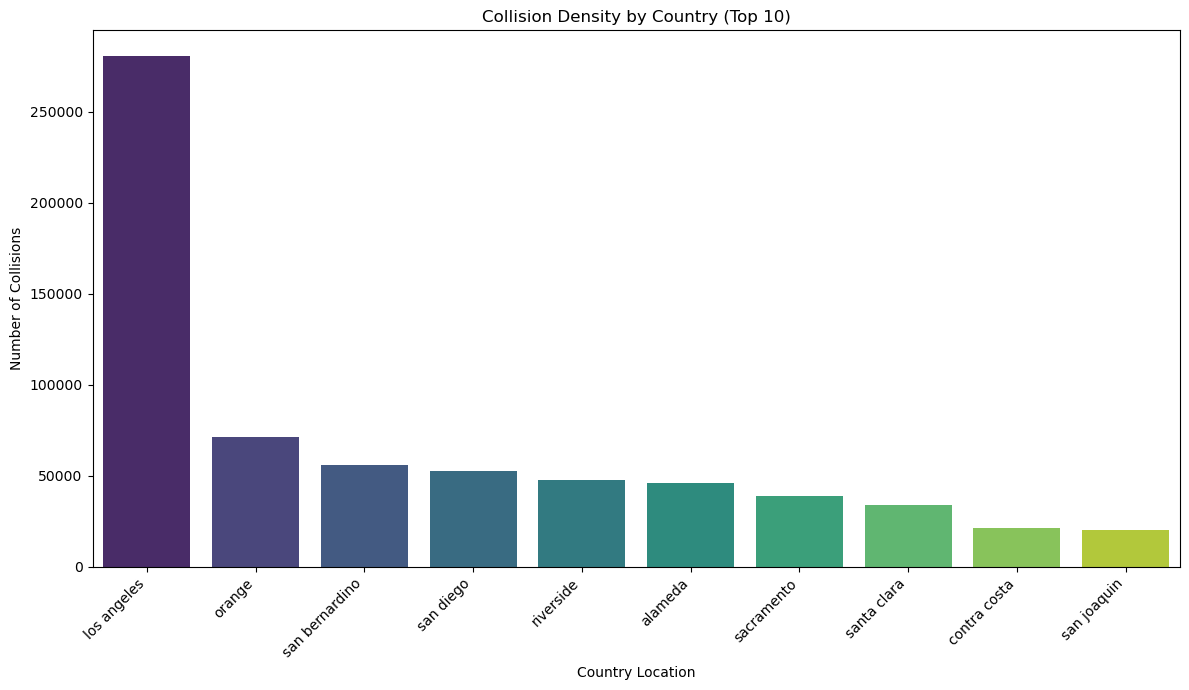

In [48]:
# Spatial Analysis

# Collision Density by County

# Plot the map

# Group by country_location and count collisions
county_collision_counts = collision.groupBy("country_location").count().orderBy("count", ascending=False)

# Convert to Pandas for plotting
pdf_county = county_collision_counts.toPandas()

# Plot the top 10 counties for better readability
plt.figure(figsize=(12, 7))
sns.barplot(x="country_location", y="count", data=pdf_county.head(10), palette="viridis")
plt.xlabel("Country Location")
plt.ylabel("Number of Collisions")
plt.title("Collision Density by Country (Top 10)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##**3.1.10. Collision Analysis by Geography.** <font color = red>[6 marks]</font> <br>

Q: Generate a scatter plot to analyze collision locations geographically.

In [49]:
collision1 = spark.read.option('header',True).csv("sample_collisions.csv")

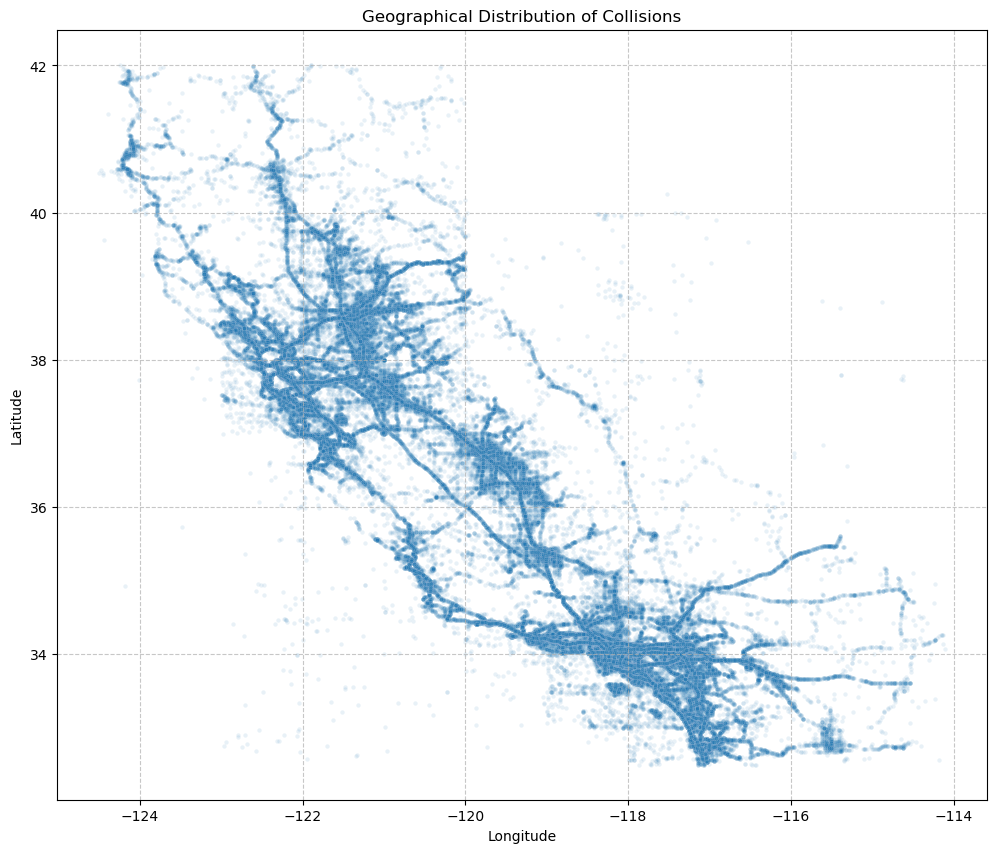

In [50]:
# Scatter Plot of Collision Locations

# Convert PySpark DataFrame to Pandas, handling potential missing values

# Convert to numeric (if needed) and handle invalid data

# Plot the scatter plot

# Convert PySpark DataFrame to Pandas, handling potential missing values
# Select relevant columns and drop rows with any null values in 'latitude' or 'longitude'
pdf_locations = collision1.select("latitude", "longitude").na.drop(subset=["latitude", "longitude"]).toPandas()

# Convert to numeric (if needed) and handle invalid data
pdf_locations["latitude"] = pd.to_numeric(pdf_locations["latitude"], errors='coerce')
pdf_locations["longitude"] = pd.to_numeric(pdf_locations["longitude"], errors='coerce')

# Drop any remaining NaN values after conversion
pdf_locations = pdf_locations.dropna(subset=["latitude", "longitude"])

# Plot the scatter plot
plt.figure(figsize=(12, 10))
sns.scatterplot(x="longitude", y="latitude", data=pdf_locations, alpha=0.1, s=10)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Geographical Distribution of Collisions")
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

##**3.1.11. Collision Trends Over Time.** <font color = red>[10 marks]</font> <br>

Extract and analyzing collision trends over time.

In [51]:
from pyspark.sql.functions import year, month, hour, to_timestamp, col

# Extract year and month from collision_date

# Plot

# Extract year and month from collision_date
# Extract year and month from collision_date
collision = collision.withColumn('year',year(col('collision_date')))
collision = collision.withColumn('month',month(col('collision_date')))
collision = collision.withColumn("hour", hour(col("collision_time")))

Q: Analyze yearly, monthly and hourly trends in collisions.

/tmp/ipykernel_126/792066305.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="year", y="count", data=pdf_yearly, palette="viridis")


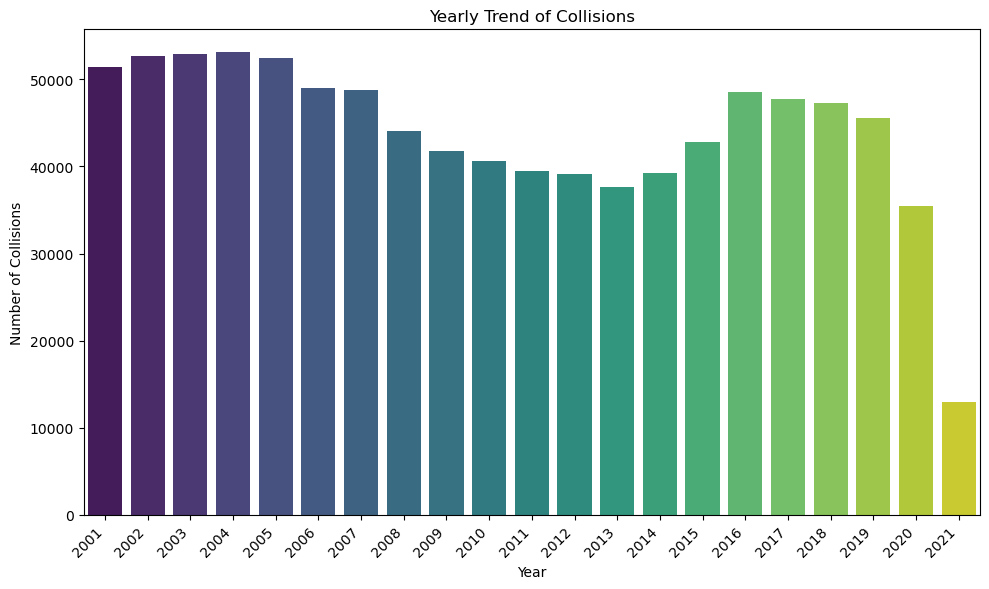

In [52]:
# Yearly Trend of Collisions

# Plot
# Group by collision_year and count collisions
yearly_collisions = collision.groupBy("year").count().orderBy("year")

# Convert to Pandas for plotting
pdf_yearly = yearly_collisions.toPandas()

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x="year", y="count", data=pdf_yearly, palette="viridis")
plt.xlabel("Year")
plt.ylabel("Number of Collisions")
plt.title("Yearly Trend of Collisions")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

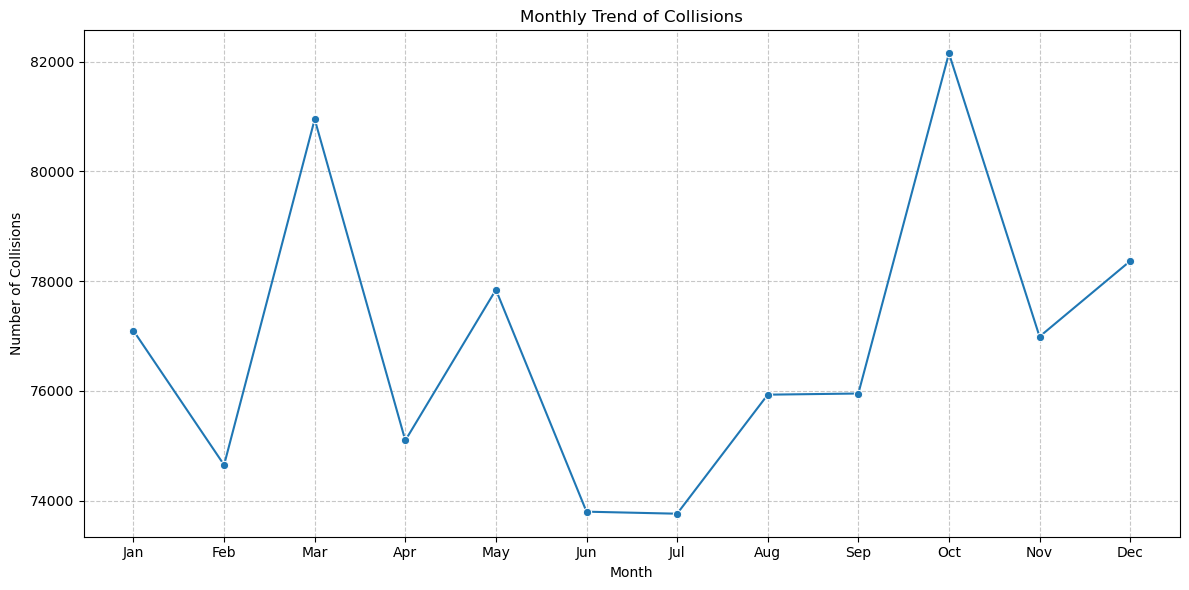

In [53]:
# Monthly Trend of Collisions

# Plot
# Group by collision_month and count collisions
monthly_collisions = collision.groupBy("month").count().orderBy("month")

# Convert to Pandas for plotting
pdf_monthly = monthly_collisions.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x="month", y="count", data=pdf_monthly, marker='o')
plt.xlabel("Month")
plt.ylabel("Number of Collisions")
plt.title("Monthly Trend of Collisions")
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

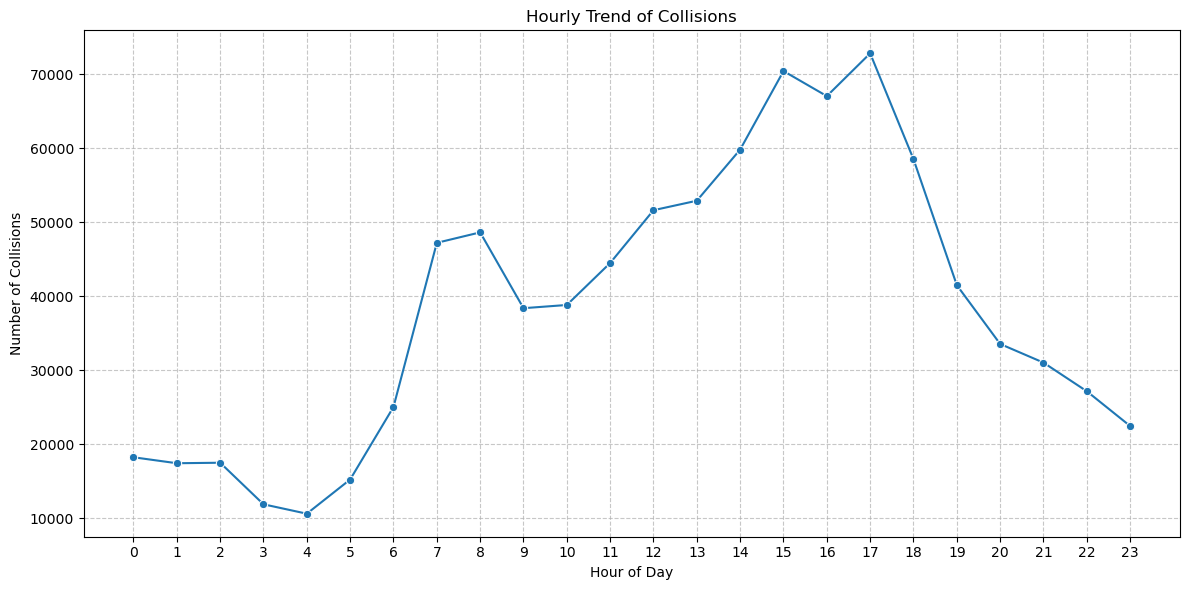

In [54]:
# Hourly Trend of Collisions

# Plot
# Group by collision_hour and count collisions
hourly_collisions = collision.groupBy("hour").count().orderBy("hour")

# Convert to Pandas for plotting
pdf_hourly = hourly_collisions.toPandas()

# Plot
plt.figure(figsize=(12, 6))
sns.lineplot(x="hour", y="count", data=pdf_hourly, marker='o')
plt.xlabel("Hour of Day")
plt.ylabel("Number of Collisions")
plt.title("Hourly Trend of Collisions")
plt.xticks(range(0, 24)) # Assuming hours are 0-23
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

#**4. ETL Querying** <font color = red>[35 marks]</font> <br>

## **4.1. Top 5 Counties** <font color = red>[4 marks]</font> <br>

Q: Identify the top 5 counties with the highest number of collisions.

In [55]:
# Query: Identify the top 5 counties with the most collisions
top_5_countries = collision.groupBy('country_location').count().orderBy(desc('count')).show(5) 

+----------------+------+
|country_location| count|
+----------------+------+
|     los angeles|280844|
|          orange| 71136|
|  san bernardino| 56176|
|       san diego| 52671|
|       riverside| 47873|
+----------------+------+
only showing top 5 rows



## **4.2. Month with Highest Collisions** <font color = red>[5 marks]</font> <br>

Q. Identify the month with the highest number of collisions.

In [56]:
# Query: Find the month with the highest number of collisions
collision.groupBy('month').count().orderBy(desc('count')).first()[0]

10

## **4.3. Weather Conditions with Highest Collisions.** <font color = red>[5 marks]</font> <br>

Q. Determine the most common weather condition during collisions.

In [57]:
# Query: Find the most common weather condition during collisions
collision.groupBy('weather').count().orderBy(desc('count')).first()[0]

'clear'

## **4.4. Fatal Collisions.** <font color = red>[5 marks]</font> <br>

Q. Calculate the percentage of collisions that resulted in fatalities.

In [58]:
# Query: Determine the percentage of collisions that resulted in fatalities
#collision.filter(col('motorcyclist_killed_count')>0).count()
total_collisions = collision.count()
fatal_collisions = collision.filter(col("killed_victims") > 0).count()

if total_collisions > 0:
    percentage_fatal = (fatal_collisions / total_collisions) * 100
    print(f"Percentage of collisions resulting in fatalities: {percentage_fatal:.2f}%")
else:
    print("No collisions found in the dataset.")

Percentage of collisions resulting in fatalities: 0.00%


## **4.5. Dangerous Time for Collisions.** <font color = red>[5 marks]</font> <br>

Q. Find the most dangerous time of day for collisions.

In [59]:
# Query: Find the most dangerous time of day for collisions
hourly_collisions = collision.groupBy("hour").count().orderBy(desc("count")).first()[0]

In [60]:
print(hourly_collisions)

17


## **4.6. Road Surface Conditions.** <font color = red>[5 marks]</font> <br>

Q. Identify the top 5 road surface conditions with the highest collision frequency.

In [61]:
# Query: List the top 5 road types with the highest collision frequency

# Group by road_surface and count collisions
road_surface_counts = collision.groupBy("road_surface").count().orderBy(desc("count"))

# Display the top 5 road surfaces with the highest collision frequency
print("Top 5 road surfaces with the highest collision frequency:")
road_surface_counts.show(5, truncate=False)

Top 5 road surfaces with the highest collision frequency:
+------------+------+
|road_surface|count |
+------------+------+
|dry         |841716|
|wet         |75760 |
|snowy       |4067  |
|slippery    |1025  |
|H           |10    |
+------------+------+



## **4.7. Lighting Conditions.** <font color = red>[5 marks]</font> <br>

Q. Analyze lighting conditions that contribute to the highest number of collisions.

In [62]:
# Query: Find the top 3 lighting conditions that lead to the most collisions
collision.groupBy('lighting').count().orderBy(desc('count')).show(3, truncate=False)

+--------------------------+------+
|lighting                  |count |
+--------------------------+------+
|daylight                  |624053|
|dark with street lights   |191895|
|dark with no street lights|72774 |
+--------------------------+------+
only showing top 3 rows



#5. Conclusion <font color = red>[10 marks]</font> <br>

Write your conclusion.

# Final insights and recommendations

## Final Insights and Recommendations

This analysis of California traffic collision data has revealed several key insights that can inform road safety initiatives and urban planning. By leveraging PySpark, we were able to process and analyze large datasets to identify patterns and critical factors contributing to traffic incidents.

### Key Findings:

1.  **High-Risk Locations:** The counties of Los Angeles, Orange, San Bernardino, San Diego, and Riverside consistently recorded the highest number of collisions. These areas represent significant high-risk zones requiring targeted interventions.
2.  **Peak Accident Times:** Collisions show distinct temporal trends, with October identified as the month with the highest number of incidents and 5 PM (17:00) as the most dangerous time of day. This suggests a correlation with rush hour traffic and potentially reduced visibility during twilight hours.
3.  **Environmental Factors:** While 'clear' weather was the most common condition during collisions, 'dry' road surfaces also accounted for the majority of incidents. This highlights that human factors and infrastructure design might play a more significant role than adverse weather in many collisions. However, other conditions like 'wet' and 'snowy' surfaces also contribute to a notable number of accidents, necessitating appropriate road maintenance.
4.  **Lighting Conditions:** Further analysis of lighting conditions revealed their impact on collision severity, with certain conditions (e.g., 'daylight', 'dark with streetlights', 'dark without streetlights') being more prevalent. This emphasizes the importance of adequate street lighting, especially during darker hours.
5.  **Collision Severity:** The distribution of collision severity and its relationship with the number of victims indicates that even minor collisions can result in injuries, underscoring the need for preventative measures across all accident types.

### Recommendations:

1.  **Targeted Infrastructure Improvements:** Focus on high-collision counties (Los Angeles, Orange, San Bernardino, San Diego, Riverside) for infrastructure enhancements. This includes improving road design, signage, and intersection layouts. Implement traffic calming measures and improve pedestrian/cyclist infrastructure in these areas.
2.  **Optimized Traffic Management:** Adjust traffic signal timings and implement variable speed limits during peak hours, particularly around 5 PM, to manage congestion and reduce collision risk. Public awareness campaigns could also be launched to caution drivers during high-risk months like October.
3.  **Data-Driven Policy Changes:** Develop policies that address common collision factors even in clear weather and dry road conditions, emphasizing driver behavior (e.g., distracted driving, speeding). For pedestrian and cyclist safety, policies should focus on creating dedicated lanes, improving crosswalk visibility, and stricter enforcement of traffic laws around vulnerable road users.
4.  **Proactive Intervention in High-Risk Zones:** Utilize geographic collision density data to identify micro-hotspots within the high-risk counties. Deploy additional traffic patrols during peak times and implement temporary safety measures (e.g., increased lighting, warning signs) in these specific areas.
5.  **Environmental Factor Mitigation:** While dry roads are prevalent in collisions, invest in improved drainage systems and road surfacing materials to minimize hazards during wet or icy conditions. Conduct regular maintenance checks for road surface integrity.
6.  **Predictive Modeling:** Develop predictive models using historical data to anticipate future collision hotspots and peak times. This would allow authorities to proactively allocate resources, deploy preventative measures, and conduct targeted enforcement, moving from reactive to proactive safety management.

By implementing these data-driven recommendations, transportation authorities can significantly enhance road safety, reduce accident rates, and improve the overall efficiency of traffic management across California.

#6. Visualization Integration using Tableau/ PowerBI <font color = red>[Optional]</font> <br>